### Create AnnData objects for GSE135362 — Vassart 2020, mouse intestinal stem-cell bulk RNA-seq

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

GSE135362 deposits **two distinct experiments** as separate count tables. This notebook produces one AnnData per file:

| file | shape | experiment |
|---|---|---|
| `GSE135362_Lgr5-expressing_vs_KO_Intestinal_stem_cells.txt` | genes × **30 samples** | Organoid Rspo dose-response: `Lgr5-WT{5,10,30}` and `Lgr5-KO{2,7}` × `Rspo{1,2,3}` × dose `{5, 100}` ng/ml |
| `GSE135362_CPM_of_intestinal_stem_cells_expressing_or_not_Lgr5.txt` | genes × **15 samples** | In vivo timecourse: E16.5 / E18.5 / Adult duo / Adult ile / Adult cKO; `HE` (Lgr5-EGFP-DTR heterozygous = Lgr5-WT) and `KO` |

All cells in both experiments are FACS-gated on Lgr5-EGFP+ — including the KO samples, which are functional knockouts of Lgr5 but the cells still derive from the same EGFP+ sort gate. So `lgr5_status='LGR5+'` for every sample; the genotype lives in `lgr5_label_raw` (`Lgr5-WT5/10/30/HE`, `Lgr5-KO2/7/cKO`) and `condition`. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §1).

### Import packages

In [1]:
import os, re
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Helper: load a Vassart bulk count table

Both files have the same shape: `Gene-ID\tGene-Name\t<sample columns>`. Genes are rows, samples are columns; transpose to AnnData layout.

In [2]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE135362'

def load_vassart_table(path):
    df = pd.read_csv(path, sep='\t')
    var = df[['Gene-ID', 'Gene-Name']].rename(columns={'Gene-ID': 'gene_id', 'Gene-Name': 'gene_name'}).set_index('gene_name')
    var.index.name = None
    expr = df.drop(columns=['Gene-ID', 'Gene-Name']).set_index(df['Gene-Name'].values)  # samples on columns
    expr.index.name = None
    obs = pd.DataFrame(index=expr.columns)
    obs.index.name = 'sample'
    a = ad.AnnData(X=sci.sparse.csr_matrix(expr.T.values), obs=obs, var=var)
    a.var_names_make_unique()
    return a

### Experiment 1 — organoid Rspo dose-response (30 samples)

Sample names encode `Org_Sample{N}_Lgr5-{WT5|WT10|WT30|KO2|KO7}_{Rspo1|Rspo2|Rspo3}-{5|100}`. Parse with a regex.

In [3]:
adata_org = load_vassart_table(os.path.join(DATA_DIR, 'GSE135362_Lgr5-expressing_vs_KO_Intestinal_stem_cells.txt'))

pattern = re.compile(r'Org_Sample(?P<sample_id>\d+)_Lgr5-(?P<genotype>WT\d+|KO\d+)_(?P<rspo>Rspo[123])-(?P<dose>\d+)')
parsed = adata_org.obs.index.to_series().str.extract(pattern)
adata_org.obs['sample_id'] = parsed['sample_id'].values
adata_org.obs['lgr5_label_raw'] = ('Lgr5-' + parsed['genotype']).values  # Lgr5-WT5, Lgr5-KO7, ...
adata_org.obs['rspo_ligand'] = parsed['rspo'].values
adata_org.obs['rspo_dose_ngml'] = parsed['dose'].astype(int).values
adata_org.obs['condition'] = (parsed['rspo'] + '-' + parsed['dose']).values
adata_org.obs['cell_type'] = 'Lgr5+ ISC organoid'
adata_org.obs['tissue'] = 'intestinal organoid'
adata_org.obs['lgr5_status'] = 'LGR5+'
adata_org.obs['GSE'] = 'GSE135362'
adata_org.obs['organism'] = 'mus musculus'
adata_org.obs['technology'] = 'bulk RNA-seq Illumina'
adata_org.obs['assay_modality'] = 'bulk'
adata_org.obs['experiment'] = 'organoid_Rspo_dose_response'
for col in ['sample_id', 'lgr5_label_raw', 'rspo_ligand', 'condition', 'cell_type', 'tissue', 'lgr5_status', 'GSE', 'organism', 'technology', 'assay_modality', 'experiment']:
    adata_org.obs[col] = adata_org.obs[col].astype('category')
adata_org.obs[['lgr5_label_raw', 'rspo_ligand', 'rspo_dose_ngml']].value_counts(dropna=False)

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


lgr5_label_raw  rspo_ligand  rspo_dose_ngml
Lgr5-KO2        Rspo1        5                 1
                             100               1
Lgr5-WT5        Rspo3        5                 1
                Rspo2        100               1
                             5                 1
                Rspo1        100               1
                             5                 1
Lgr5-WT30       Rspo3        100               1
                             5                 1
                Rspo2        100               1
                             5                 1
                Rspo1        100               1
                             5                 1
Lgr5-WT10       Rspo3        100               1
                             5                 1
                Rspo2        100               1
                             5                 1
                Rspo1        100               1
                             5                 1
Lgr5-KO7        Rspo3    

### Experiment 2 — in vivo HE vs KO timecourse (15 samples)

Sample names encode the developmental stage and genotype, e.g. `E16.5_Lgr5_HE_pool_1`, `Adult_Duo_HE_Sample_S1`, `Adult_cKO_Sample_2`. Hand-mapped because the schema isn't fully regular.

In [4]:
adata_vivo = load_vassart_table(os.path.join(DATA_DIR, 'GSE135362_CPM_of_intestinal_stem_cells_expressing_or_not_Lgr5.txt'))

INVIVO_META = {
    'E16.5_Lgr5_HE_pool_1':       dict(stage='E16.5',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='E16.5'),
    'E16.5_Lgr5_KO_pool_1':       dict(stage='E16.5',     genotype='KO',  tissue='small intestine',                  lgr5_label_raw='Lgr5-KO',  condition='E16.5'),
    'E16.5_Lgr5_HE_pool_2':       dict(stage='E16.5',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='E16.5'),
    'E16.5_Lgr5_KO_pool_2':       dict(stage='E16.5',     genotype='KO',  tissue='small intestine',                  lgr5_label_raw='Lgr5-KO',  condition='E16.5'),
    'E18.5_HE_Sample_S1':         dict(stage='E18.5',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='E18.5'),
    'E18.5_HE_Sample_S2':         dict(stage='E18.5',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='E18.5'),
    'Adult_Duo_HE_Sample_S1':     dict(stage='Adult',     genotype='HE',  tissue='duodenum',                         lgr5_label_raw='Lgr5-HE',  condition='Adult-duo'),
    'Adult_Ile_HE_Sample_S1':     dict(stage='Adult',     genotype='HE',  tissue='ileum',                            lgr5_label_raw='Lgr5-HE',  condition='Adult-ile'),
    'Adult_Duo_HE_Sample_S2':     dict(stage='Adult',     genotype='HE',  tissue='duodenum',                         lgr5_label_raw='Lgr5-HE',  condition='Adult-duo'),
    'Adult_Ile_HE_Sample_S2':     dict(stage='Adult',     genotype='HE',  tissue='ileum',                            lgr5_label_raw='Lgr5-HE',  condition='Adult-ile'),
    'Adult_HE_Sample_1':          dict(stage='Adult',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='Adult'),
    'Adult_HE_Sample_2':          dict(stage='Adult',     genotype='HE',  tissue='small intestine',                  lgr5_label_raw='Lgr5-HE',  condition='Adult'),
    'Adult_cKO_Sample_1':         dict(stage='Adult',     genotype='cKO', tissue='small intestine',                  lgr5_label_raw='Lgr5-cKO', condition='Adult-cKO'),
    'Adult_cKO_Sample_2':         dict(stage='Adult',     genotype='cKO', tissue='small intestine',                  lgr5_label_raw='Lgr5-cKO', condition='Adult-cKO'),
    'Adult_cKO_Sample_3':         dict(stage='Adult',     genotype='cKO', tissue='small intestine',                  lgr5_label_raw='Lgr5-cKO', condition='Adult-cKO'),
}
missing = set(adata_vivo.obs.index) - set(INVIVO_META)
extra   = set(INVIVO_META) - set(adata_vivo.obs.index)
if missing or extra:
    raise ValueError(f'INVIVO_META mismatch — missing in map: {missing}; not in data: {extra}')

for col in ['stage', 'genotype', 'tissue', 'lgr5_label_raw', 'condition']:
    adata_vivo.obs[col] = adata_vivo.obs.index.map(lambda s: INVIVO_META[s][col])
adata_vivo.obs['cell_type'] = 'Lgr5+ ISC primary'
adata_vivo.obs['lgr5_status'] = 'LGR5+'
adata_vivo.obs['GSE'] = 'GSE135362'
adata_vivo.obs['organism'] = 'mus musculus'
adata_vivo.obs['technology'] = 'bulk RNA-seq Illumina'
adata_vivo.obs['assay_modality'] = 'bulk'
adata_vivo.obs['experiment'] = 'invivo_HE_vs_KO_timecourse'
for col in ['stage', 'genotype', 'tissue', 'lgr5_label_raw', 'condition', 'cell_type', 'lgr5_status', 'GSE', 'organism', 'technology', 'assay_modality', 'experiment']:
    adata_vivo.obs[col] = adata_vivo.obs[col].astype('category')
adata_vivo.obs[['stage', 'genotype', 'tissue', 'lgr5_label_raw']].value_counts(dropna=False)

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


stage  genotype  tissue           lgr5_label_raw
Adult  cKO       small intestine  Lgr5-cKO          3
       HE        duodenum         Lgr5-HE           2
                 ileum            Lgr5-HE           2
                 small intestine  Lgr5-HE           2
E16.5  HE        small intestine  Lgr5-HE           2
       KO        small intestine  Lgr5-KO           2
E18.5  HE        small intestine  Lgr5-HE           2
Name: count, dtype: int64

### Sanity check — Lgr5 / Olfm4 / Ascl2 in HE vs KO

In the in vivo timecourse, KO samples should have visibly lower Lgr5 (functional KO at the transcript level).

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2074: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in [*adata.obs_keys(), adata.obs.index.name]:


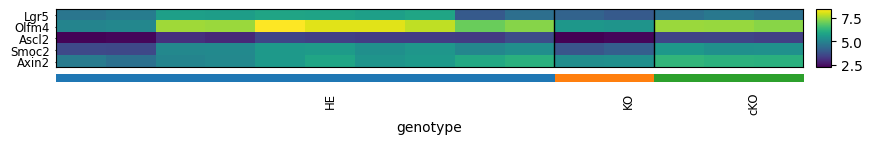

In [5]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2'] if g in adata_vivo.var_names]
if isc_markers:
    sc.pl.heatmap(adata_vivo, var_names=isc_markers, groupby='genotype', swap_axes=True, log=True, dendrogram=False)

### Record provenance and save (one h5ad per experiment)

In [6]:
out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

for tag, a, src in [
    ('organoid', adata_org,  'GSE135362_Lgr5-expressing_vs_KO_Intestinal_stem_cells.txt'),
    ('invivo',   adata_vivo, 'GSE135362_CPM_of_intestinal_stem_cells_expressing_or_not_Lgr5.txt'),
]:
    a.uns['GSE'] = 'GSE135362'
    a.uns['publication'] = 'Fernandez Vallone V et al., EMBO Reports 21:e49224 (2020) — LGR5 controls extracellular matrix production by stem cells in the developing intestine'
    a.uns['genome_reference'] = 'mm10 (per Vassart 2020 — Ensembl gene IDs preserved in var)'
    a.uns['source_files'] = [src]
    a.uns['processing_history'] = {
        timestamp: f'AnnData created from GSE135362 {tag} bulk RNA-seq table; transposed genes×samples → samples×genes; lgr5_status=LGR5+ (HE and KO are both Lgr5-EGFP+ FACS-gated); QC metrics not relevant for bulk; no filtering applied.',
    }
    out_path = f'{out_dir}/gut_mm_GSE135362_{tag}_AM_{timestamp}_raw.h5ad'
    a.write_h5ad(out_path)
    print(out_path, a.shape)

data/LGR5_analysis/gut_mm_GSE135362_organoid_AM_07052026_233728_raw.h5ad (30, 52636)
data/LGR5_analysis/gut_mm_GSE135362_invivo_AM_07052026_233728_raw.h5ad (15, 52636)
